In [151]:
from gensim.models import word2vec
from tensorflow.keras import preprocessing
import matplotlib.pyplot as plt
from pyvi import ViTokenizer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cleandt
from embedding import PatchEmbedding, MeanVectorizer

## Import and normalize data

In [152]:
news = pd.read_csv('../data/data_origin/Trainfull.csv') 
print(news.shape)

(8898, 5)


In [153]:
print(news.info())
news.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8898 entries, 0 to 8897
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      8898 non-null   int64 
 1   comment    8898 non-null   object
 2   n_star     8898 non-null   int64 
 3   date_time  8898 non-null   object
 4   label      8898 non-null   object
dtypes: int64(2), object(3)
memory usage: 347.7+ KB
None


,index,comment,n_star,date_time,label
0,0,Mới mua máy này Tại thegioididong thốt nốt cảm...,5,2 tuần trước,{CAMERA#Positive};{FEATURES#Positive};{BATTERY...
1,1,Pin kém còn lại miễn chê mua 8/3/2019 tình trạ...,5,14/09/2019,{BATTERY#Negative};{GENERAL#Positive};{OTHERS};
2,2,Sao lúc gọi điện thoại màn hình bị chấm nhỏ nh...,3,17/08/2020,{FEATURES#Negative};
3,3,"Mọi người cập nhật phần mềm lại , nó sẽ bớt tố...",3,29/02/2020,{FEATURES#Negative};{BATTERY#Neutral};{GENERAL...
4,4,"Mới mua Sài được 1 tháng thấy pin rất trâu, Sà...",5,4/6/2020,{BATTERY#Positive};{PERFORMANCE#Positive};{SER...


In [154]:
news.isna().sum()

index        0
comment      0
n_star       0
date_time    0
label        0
dtype: int64

In [155]:
news.dropna(axis=0, inplace=True)
news.reset_index(inplace=True)
news.drop(columns=['index'], axis=1, inplace=True)

In [156]:
news['comment'] = news['comment'].apply(lambda x: cleandt.remove_stopword(x, '../data/data_stopword/vietnamese-stopwords.txt'))

In [157]:
# print(news['label'].value_counts())
# news.head()

In [158]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Đếm số lượng mỗi nhãn
# label_counts = news['label'].value_counts()

# # Trực quan hóa bằng biểu đồ thanh
# plt.figure(figsize=(10, 6))
# sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
# plt.title('Distribution of Sentiment Labels')
# plt.xlabel('Sentiment Label')
# plt.ylabel('Count')
# plt.show()

# # Trực quan hóa bằng biểu đồ tròn
# plt.figure(figsize=(8, 8))
# plt.pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(label_counts)))
# plt.title('Distribution of Sentiment Labels')
# plt.show()


## Create word embedding model from Word2Vec

In [159]:
sequences = news['comment'].to_list()
input_gensim = []

for sen in sequences:
  input_gensim.append(sen.split())

In [160]:
model = word2vec.Word2Vec(input_gensim, vector_size=128, window=5, min_count=0, workers=4, sg=1)
model.save("../model/word2vec_no_label.model")

In [161]:
model = word2vec.Word2Vec.load("../model/word2vec_no_label.model")

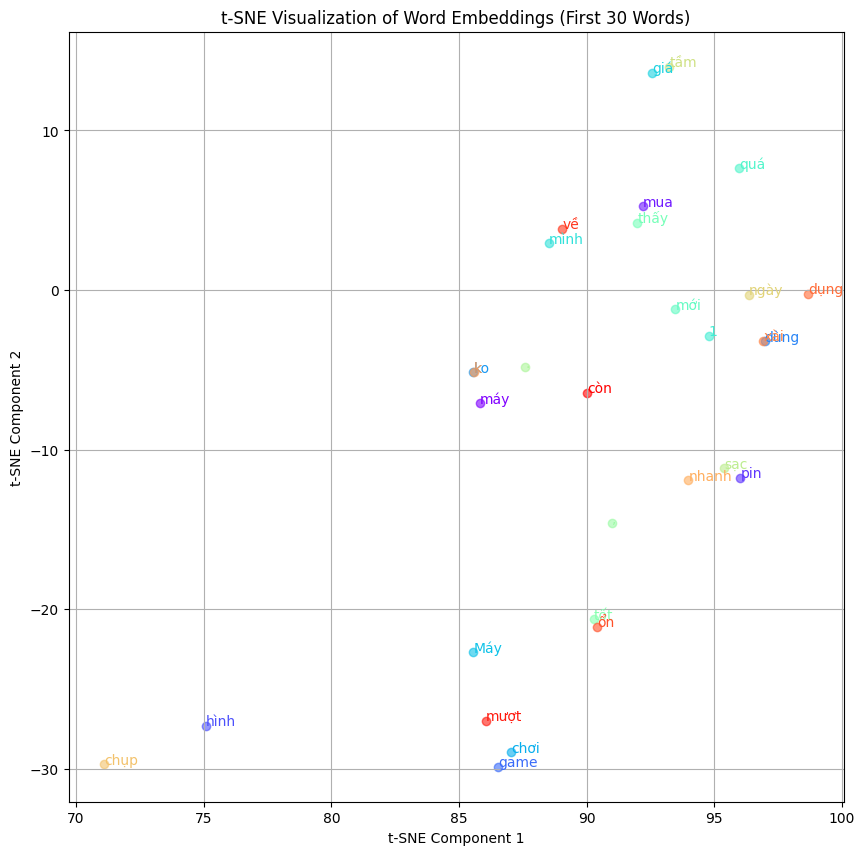

In [162]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Lấy các từ và vector từ mô hình
words = list(model.wv.index_to_key)
word_vectors = model.wv[words]

# Giảm chiều dữ liệu xuống 2 chiều bằng t-SNE
tsne = TSNE(n_components=2, random_state=42)
word_vecs_2d = tsne.fit_transform(word_vectors)

# Trực quan hóa các vectơ từ
plt.figure(figsize=(10, 10))
num_words = 30
# Màu cho mỗi từ
colors = plt.cm.rainbow(np.linspace(0, 1, num_words))

# Vẽ các điểm dữ liệu (từ) với màu khác nhau
for i, word in enumerate(words[:num_words]):  
    plt.scatter(word_vecs_2d[i, 0], word_vecs_2d[i, 1], marker='o', color=colors[i], alpha=0.6)
    plt.annotate(word, xy=(word_vecs_2d[i, 0], word_vecs_2d[i, 1]), fontsize=10, color=colors[i])

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE Visualization of Word Embeddings (First 30 Words)')
plt.grid(True)
plt.show()


## Find similar texts by Cosine measure

In [163]:
question = '''
mình mua máy samsung a20s 4 ngày nói_chung máy xài ổn trong tầm giá pin trâu chơi game xài 2 đến 3 ngày còn chơi game liên_quân tầm 1 ngày chụp hình đẹp máy mượt lâu_lâu cảm_biến vân tay nhạy ngón tay hơi ướt xíu máy nhận vân tay luôn ốp lưng xài hơi xót xíu mình làm trong môi_trường chăn_nuôi bụi cám kia
'''

In [164]:
pemb = PatchEmbedding(word_model=model, stopword_path="../data/data_stopword/vietnamese-stopwords.txt")

question_embeddings = pemb.sentence_embedding(question)
post_embeddings = pemb.post_embedding(input_gensim, length=len(input_gensim))

After tonkenized: 
 mình mua máy samsung a20s 4 ngày nói_chung máy xài ổn trong tầm giá pin trâu chơi game xài 2 đến 3 ngày còn chơi game liên_quân tầm 1 ngày chụp hình đẹp máy mượt lâu_lâu cảm_biến vân tay nhạy ngón tay hơi ướt xíu máy nhận vân tay luôn ốp lưng xài hơi xót xíu mình làm trong môi_trường chăn_nuôi bụi cám kia 



In [165]:
print(len(question_embeddings))
question_embeddings[0]

58


array([ 2.01907679e-01, -4.77427751e-01,  5.42784393e-01,  3.19851130e-01,
        6.27820417e-02, -8.75314400e-02,  1.02508314e-01, -7.28833601e-02,
       -2.29111984e-01,  2.16388643e-01,  3.84999007e-01, -4.20740768e-02,
       -1.52810857e-01, -1.49536669e-01,  2.36760572e-01,  3.87411416e-01,
       -2.37153605e-01, -1.69764385e-01,  9.58603546e-02,  4.89662923e-02,
        2.94983406e-02,  5.08561850e-01, -2.67152190e-01, -6.63780808e-01,
       -5.82841933e-01,  7.13757798e-02, -4.47771400e-01,  9.67616737e-02,
        3.94189179e-01, -1.17201887e-01,  1.77246422e-01,  3.04866940e-01,
        6.26970008e-02,  3.11655968e-01, -1.68853402e-01,  5.13131857e-01,
        6.47096932e-01, -2.14340612e-01,  1.90906793e-01, -1.02747224e-01,
       -1.26319259e-01,  1.10820137e-01, -1.12992510e-01,  5.61756408e-03,
        4.43996280e-01,  2.25695185e-02, -4.29748595e-01,  3.03853303e-02,
        7.17884451e-02,  4.12558079e-01,  2.11819381e-01,  9.92608815e-02,
        4.16393310e-01,  

In [166]:
mvectorize = MeanVectorizer(word_model=model)

mean_sentence_embedding = mvectorize.mean_vector_embedding(question_embeddings)
mean_post_embedding = mvectorize.mean_posts_embedding(post_embeddings)

In [167]:
print('The len of the mean embedding vector:', len(mean_sentence_embedding))
print('The length of the mean embedding posts:', len(mean_post_embedding))

# Calculate similarity (cosine similarity)
similarity_score = mvectorize.text_cosine_similarity(mean_sentence_embedding, mean_post_embedding)

# Print the similarity score
print(f"Similarity Score: {similarity_score}")

The len of the mean embedding vector: 128
The length of the mean embedding posts: 8898
Similarity Score: [[0.9502958  0.94715565 0.91410214 ... 0.9386971  0.9272794  0.88862836]]


In [168]:
similar_news = mvectorize.find_similarity(similarity_score, news)

np_similarity_scores [[0.9502958  0.94715565 0.91410214 ... 0.9386971  0.9272794  0.88862836]]
Sorted Indices: [  30 7249 4241 ... 4939 3465 2136]
Top 5 Indices: [  30 7249 4241 1272 4198]


In [169]:
similar_news

,level_0,comment,n_star,date_time,label
30,30,Mình mua máy samsung a20s 4 ngày rồi. Nói chun...,5,24/10/2019,{CAMERA#Positive};{FEATURES#Negative};{BATTERY...
7249,7249,Tui mới mua 3 ngày thấy ok nhận diện khuôn m...,4,2/5/2020,{SCREEN#Negative};{CAMERA#Positive};{FEATURES#...
4241,4241,"Mua máy VivoU10 tầm nửa tháng rồi, Lúc mình mu...",4,13/03/2020,{CAMERA#Negative};{FEATURES#Neutral};{BATTERY#...
1272,1272,Mình mua trong tết sài hơn hai tháng \r\nDạo g...,5,17/04/2020,{CAMERA#Positive};{FEATURES#Negative};{PERFORM...
4198,4198,mới mua 3 ngày máy củ sử dụng giá 8t5 bảo hành...,5,30/05/2020,{CAMERA#Positive};{FEATURES#Neutral};{BATTERY#...


## Visualize the relationships

* The relationships among words

In [170]:
from sklearn.decomposition import PCA

In [171]:
def words_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [word for word in model.wv.vocab]
        
    word_vectors = np.array([model.wv[w] for w in words])
    
    twodim = PCA().fit_transform(word_vectors)[:,:2]
    
    plt.figure(figsize=(6,6))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        plt.text(x+0.05, y-0.50, word)

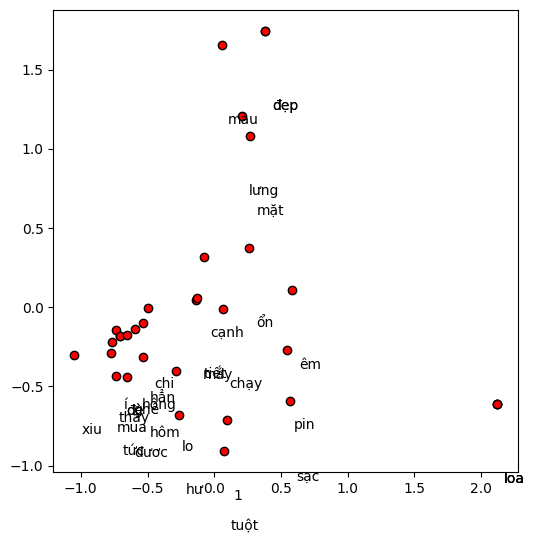

In [175]:
sentence = '''tất_cả mọi thứ ổn hết màn_hình đẹp máy chạy êm pin sạc nhanh màu mặt lưng đẹp tiết ở phần thiết_kế chi loa ngoài đặt ở bên hông thay đặt ở cạnh tay đè loa sử_dụng í lo chính bản_thân đè quá làm loa hư thêm 1 nhỏ_xíu xiu mới mua hôm giảm 500000đ nay xem tuột xuống đươc giảm hẳn 1000000đ tức ghê'''

sentence = sentence.lower()
sentence = cleandt.remove_punctuation(sentence)
sentence = ViTokenizer.tokenize(sentence)
sentence = cleandt.remove_stopword(sentence, '../data/data_stopword/vietnamese-stopwords-dash.txt')
words = sentence.split()

words_scatterplot(model, words)

* The relationships among documents

In [176]:
temp_embeddings = pemb.post_embedding(input_gensim, 100)
mean_temp_embedding = mvectorize.mean_posts_embedding(temp_embeddings)

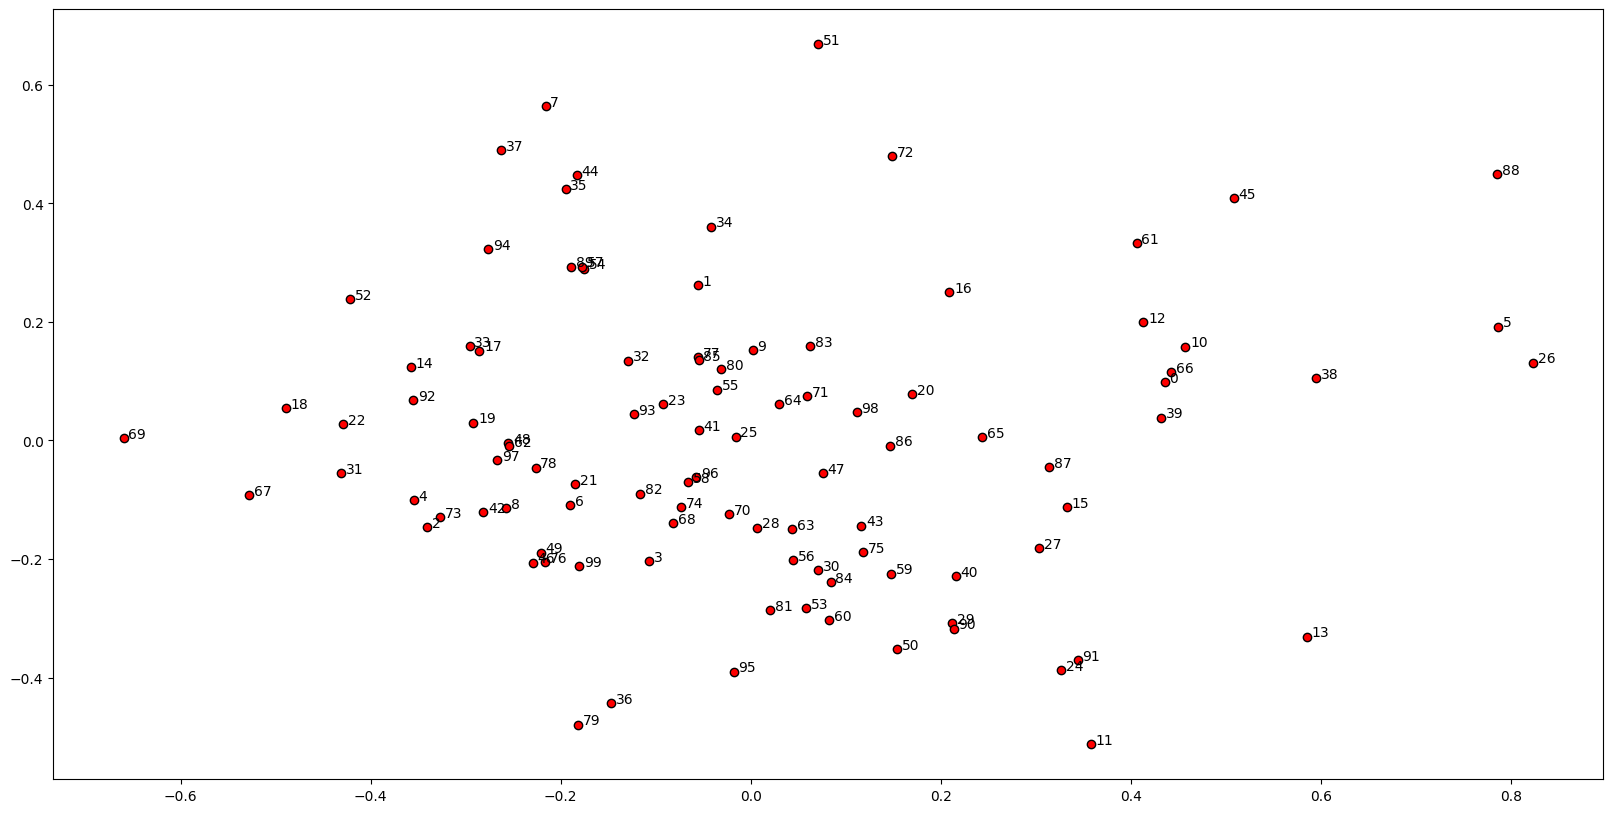

In [177]:
# mean_post_embedding
post_vectors = []
for post_embedding in mean_temp_embedding:
    post_vectors.append(post_embedding.tolist())

twodim = PCA().fit_transform(post_vectors)[:,:2]
index = [i for i,_ in enumerate(mean_temp_embedding)]

plt.figure(figsize=(20,10))
plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
for doc, (x,y) in zip(index, twodim):
    plt.text(x+0.005, y, doc)

## Text clustering with Kmean algorithm

In [178]:
text_embeddings = pemb.post_embedding(input_gensim)
    
print(len(text_embeddings))
print(len(text_embeddings[0]))

8898
34


In [179]:
mean_text_embeddings = mvectorize.flatten_mean_embedding(text_embeddings)
print(len(mean_text_embeddings))

100%|██████████| 8898/8898 [00:03<00:00, 2821.20it/s] 

8898


In [180]:
# Đệm thêm 0 để đủ độ dài trong từng văn bản
max_length = max([len(i) for i in mean_text_embeddings])
mean_text_embeddings_padding = np.array(preprocessing.sequence.pad_sequences(mean_text_embeddings, maxlen=max_length, padding='pre', dtype='float32'))

In [181]:
from clusteval import clusteval
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import numpy as np

In [182]:
print("The shape of padding sequences array:", mean_text_embeddings_padding.shape)
print(mean_text_embeddings_padding[0:5])

The shape of padding sequences array: (8898, 165)
[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000

In [183]:
# Set parameters, as an example dbscan
ce = clusteval(evaluate='silhouette', max_clust=20, normalize=True)

# Fit to find optimal number of clusters using dbscan
results = ce.fit(mean_text_embeddings_padding)

[clusteval] >INFO> Normalizing input data per feature (zero mean and unit variance)


[clusteval] >INFO> Saving data in memory.
[clusteval] >INFO> Fit with method=[agglomerative], metric=[euclidean], linkage=[ward]
[clusteval] >INFO> Evaluate using silhouette.
[clusteval] >INFO: 100%|██████████| 18/18 [00:32<00:00,  1.79s/it]
[clusteval] >INFO> Compute dendrogram threshold.
[clusteval] >INFO> Optimal number clusters detected: [2].
[clusteval] >INFO> Fin.


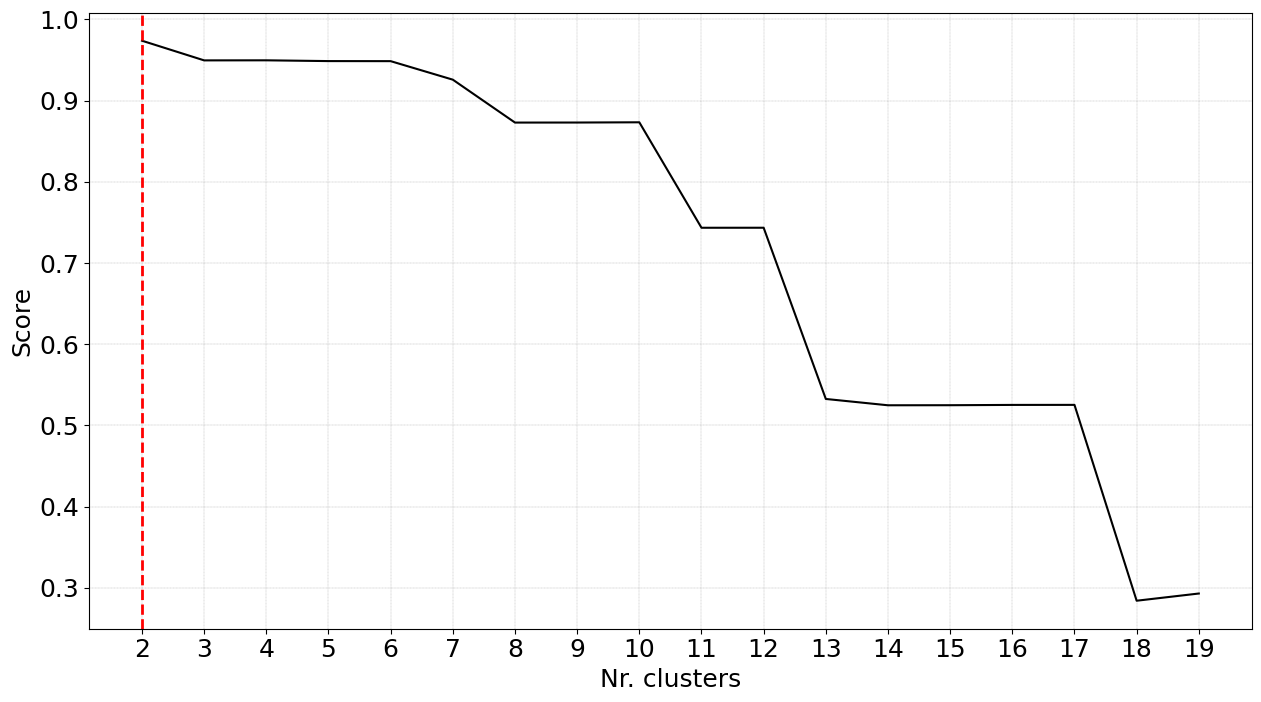

(<Figure size 1500x800 with 1 Axes>,
 <Axes: xlabel='Nr. clusters', ylabel='Score'>)

In [184]:
ce.plot(verbose=0)

c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\clus

Text(0, 0.5, 'Sum of squared distance')

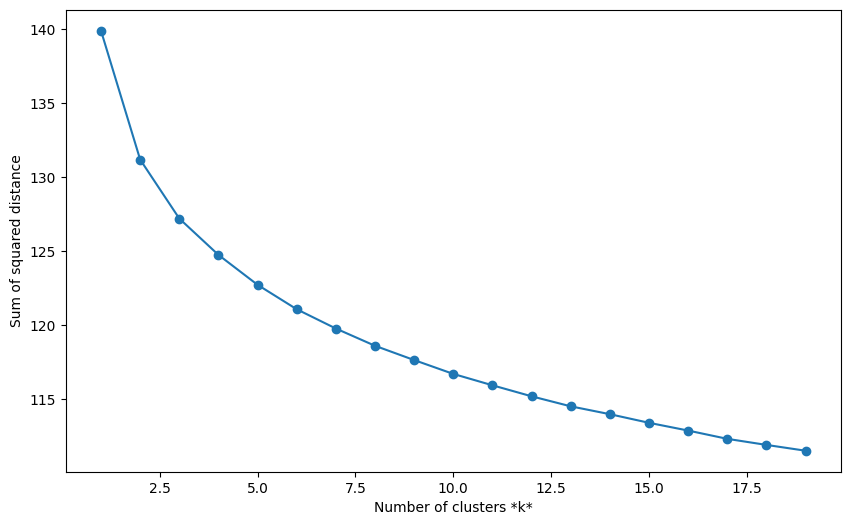

In [185]:
# Run the Kmeans algorithm and get the index of data points clusters
sse = []
list_k = list(range(1, 20))

for k in list_k:
    km = KMeans(n_clusters=k)
    km.fit(mean_text_embeddings_padding)
    sse.append(km.inertia_)

# Plot sse against k
plt.figure(figsize=(10, 6))
plt.plot(list_k, sse, '-o')
plt.xlabel(r'Number of clusters *k*')
plt.ylabel('Sum of squared distance')

In [189]:
kmeans = KMeans(n_clusters=9, verbose=1).fit(mean_text_embeddings_padding)
text_clustering = kmeans.predict(mean_text_embeddings_padding)

c:\Users\dtptr\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Initialization complete
Iteration 0, inertia 147.17654418945312.
Iteration 1, inertia 123.20922088623047.
Iteration 2, inertia 119.89971160888672.
Iteration 3, inertia 118.87161254882812.
Iteration 4, inertia 118.4489974975586.
Iteration 5, inertia 118.26889038085938.
Iteration 6, inertia 118.17972564697266.
Iteration 7, inertia 118.13349151611328.
Iteration 8, inertia 118.09724426269531.
Iteration 9, inertia 118.0676040649414.
Iteration 10, inertia 118.04450225830078.
Iteration 11, inertia 118.02349853515625.
Iteration 12, inertia 118.00484466552734.
Iteration 13, inertia 117.98392486572266.
Iteration 14, inertia 117.9630126953125.
Iteration 15, inertia 117.9432373046875.
Iteration 16, inertia 117.92483520507812.
Iteration 17, inertia 117.9094009399414.
Iteration 18, inertia 117.89258575439453.
Iteration 19, inertia 117.87530517578125.
Iteration 20, inertia 117.86150360107422.
Iteration 21, inertia 117.85049438476562.
Iteration 22, inertia 117.84171295166016.
Iteration 23, inertia 117

In [190]:
embedding_2d = PCA().fit_transform(mean_text_embeddings_padding)[:,:2]
temp = np.append(embedding_2d, text_clustering.reshape((len(text_clustering), 1)), axis=1)
df = pd.DataFrame(temp)

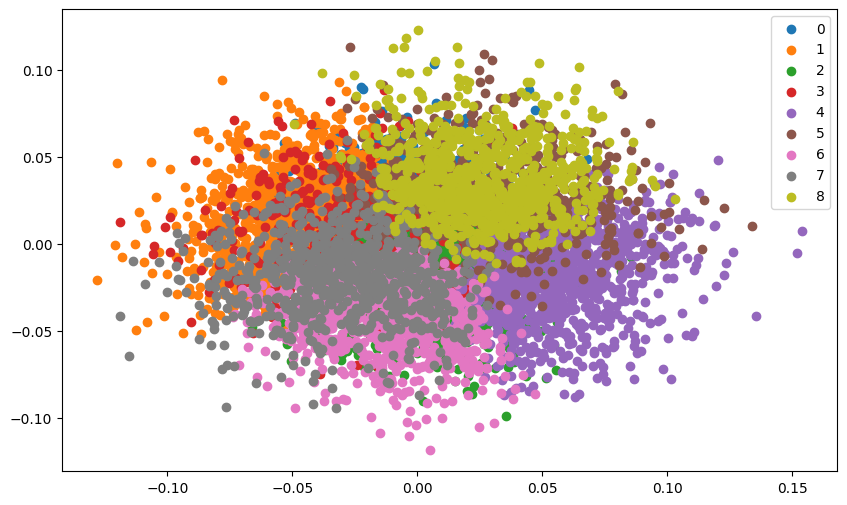

In [191]:
#Getting unique labels
u_labels = np.unique(text_clustering)

#plotting the results
plt.figure(figsize=(10, 6))
for i in u_labels:
    plt.scatter(df[df[2]==i][0] , df[df[2]==i][1], label = i)
plt.legend()
plt.show()